Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout

Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\User\Documents\GitHub\My_Ai_Course\Final Assessment\2.Deep Learning Datasets\Starlink & SpaceX Dataset\spacex_starlink (2).csv")
df

,id,spacetrack_id,version,launch_date,longitude,latitude,height_km,velocity_kms
0,5eed770f096e59000698560d,NaN,v0.9,NaN,NaN,NaN,NaN,NaN
1,5eed770f096e59000698560e,NaN,v0.9,NaN,NaN,NaN,NaN,NaN
2,5eed770f096e59000698560f,NaN,v0.9,NaN,NaN,NaN,NaN,NaN
3,5eed770f096e590006985610,NaN,v0.9,NaN,NaN,NaN,NaN,NaN
4,5eed770f096e590006985611,NaN,v0.9,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
3521,63655b77358d5951a1c69dd0,NaN,NaN,NaN,137.300802,44.268273,355.305350,7.700996
3522,63655b77358d5951a1c69dfa,NaN,NaN,NaN,153.947639,33.722400,353.712986,7.700405
3523,63655b77358d5951a1c69e37,NaN,NaN,NaN,136.668403,44.561516,355.632656,7.700673
3524,63655b77358d5951a1c69e39,NaN,NaN,NaN,143.873451,40.755340,354.996912,7.700481


EDA

In [3]:
print(df.shape)

(3526, 8)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             3526 non-null   str    
 1   spacetrack_id  0 non-null      float64
 2   version        3215 non-null   str    
 3   launch_date    0 non-null      float64
 4   longitude      3268 non-null   float64
 5   latitude       3268 non-null   float64
 6   height_km      3268 non-null   float64
 7   velocity_kms   3268 non-null   float64
dtypes: float64(6), str(2)
memory usage: 220.5 KB
None


In [5]:
print(df.describe())

       spacetrack_id  launch_date    longitude     latitude    height_km  \
count            0.0          0.0  3268.000000  3268.000000  3268.000000   
mean             NaN          NaN     2.248772     1.321539   539.588682   
std              NaN          NaN   102.982183    37.061888    45.941995   
min              NaN          NaN  -179.933614   -82.237072   303.137599   
25%              NaN          NaN   -86.384518   -32.992599   543.024058   
50%              NaN          NaN     1.907842     2.244397   549.031323   
75%              NaN          NaN    91.000716    36.505165   556.617742   
max              NaN          NaN   179.973121    82.297000   595.373243   

       velocity_kms  
count   3268.000000  
mean       7.594950  
std        0.026316  
min        7.561740  
25%        7.582612  
50%        7.591027  
75%        7.595025  
max        7.729005  


Missing Values

In [6]:
print(df.isnull().sum())

id                  0
spacetrack_id    3526
version           311
launch_date      3526
longitude         258
latitude          258
height_km         258
velocity_kms      258
dtype: int64


Convert Launch Date

In [7]:
df['launch_date'] = pd.to_datetime(df['launch_date'])

Time Series

In [8]:
time_series = df.groupby('launch_date')['height_km'].mean()

time_series = time_series.reset_index()

time_series.head()

,launch_date,height_km


Plot Time Series

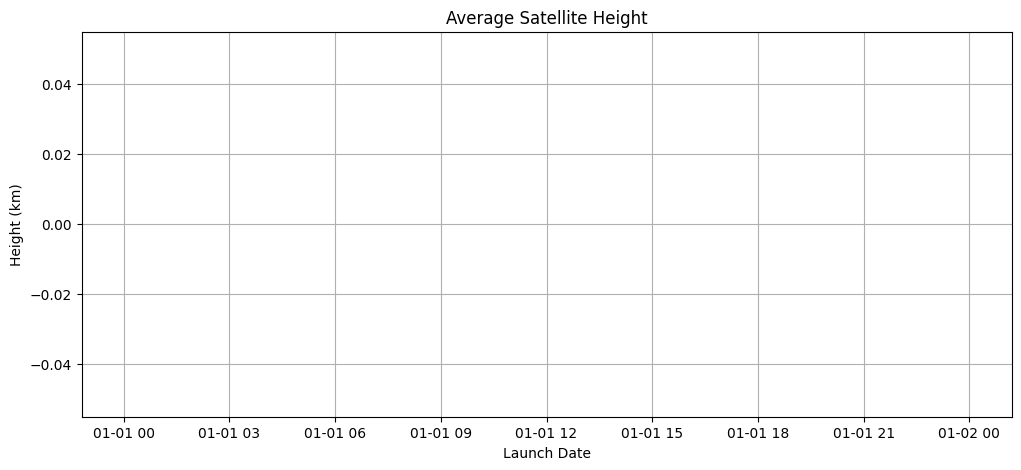

In [9]:
plt.figure(figsize=(12,5))
plt.plot(time_series['launch_date'],
         time_series['height_km'])
plt.title("Average Satellite Height")
plt.xlabel("Launch Date")
plt.ylabel("Height (km)")
plt.grid(True)
plt.show()

RNN Model

In [19]:
rnn = Sequential()
rnn.add(SimpleRNN(
    64,
    activation='tanh',
    input_shape=(time_step,1)
))
rnn.add(Dropout(0.2))
rnn.add(Dense(1))
rnn.compile(
    optimizer='adam',
    loss='mse'
)
rnn.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Model

In [18]:
lstm = Sequential()
lstm.add(LSTM(
    64,
    input_shape=(time_step,1)
))
lstm.add(Dropout(0.2))
lstm.add(Dense(1))
lstm.compile(
    optimizer='adam',
    loss='mse'
)
lstm.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

GRU Model

In [20]:
gru = Sequential()
gru.add(GRU(
    64,
    input_shape=(time_step,1)
))
gru.add(Dropout(0.2))
gru.add(Dense(1))
gru.compile(
    optimizer='adam',
    loss='mse'
)
gru.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Metrics

In [24]:
def evaluate(actual,pred,name):
    mae = mean_absolute_error(actual,pred)
    mse = mean_squared_error(actual,pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual,pred)
    print("="*30)
    print(name)
    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE:",rmse)
    print("R2 :",r2)
    print("="*30)


Plot Loss

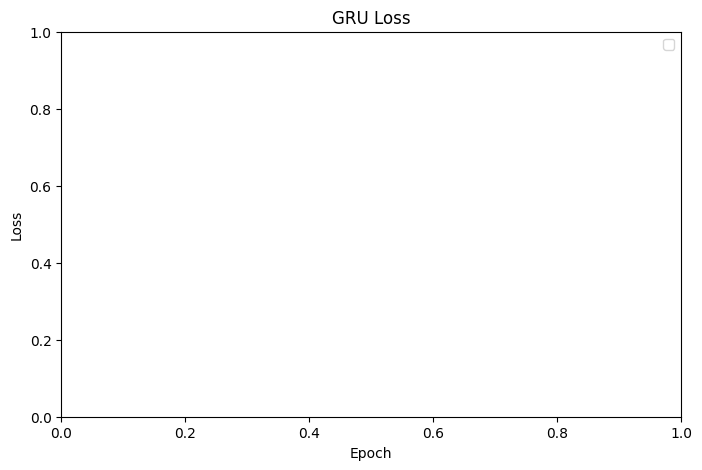

In [25]:
plt.figure(figsize=(8,5))
plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

Actual vs Prediction

C:\Users\User\AppData\Local\Temp\ipykernel_14524\1248652273.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


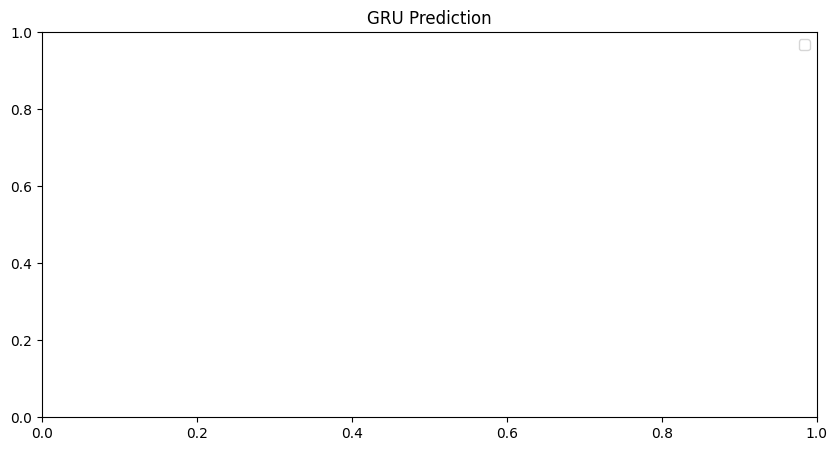

In [28]:
plt.figure(figsize=(10,5))
plt.legend()
plt.title("GRU Prediction")
plt.show()